# Analisis de BigWig dataset Plos 2016

In [1]:
from itertools import product
import pyBigWig
import os
import shlex
import subprocess
from pathlib import Path
import re
from collections import defaultdict
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
from scipy.stats import ttest_ind
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests

In [2]:
base_folder = "../assets/plos_2016"

Obs: Los (D) son infectados (Denv) y los (M) son Mock (sanos)

In [3]:
subject = ['D', 'M']
trial = ['1', '2', '3']

bigwigs = {}

for s, t in product(subject, trial):
    bigwigs[f'{s}{t}'] = f"{base_folder}/raw/bigwig/{s}{t}.bigwig"

In [4]:
import pyBigWig

bw = pyBigWig.open("../assets/plos_2016/raw/bigwig/D1.bigwig")

# 1. Header — muestra tipo de datos y estadísticas globales
print(bw.header())

# 2. Stats globales del genoma
print("mean global:", bw.stats("chr1", type="mean"))

# 3. Ver valores en un locus conocido para inferir escala
print("PML locus sample:", bw.stats("chr15", 74036006, 74047827, type="mean"))
print("PML locus max:", bw.stats("chr15", 74036006, 74047827, type="max"))

{'version': 4, 'nLevels': 6, 'nBasesCovered': 3209286105, 'minVal': 0, 'maxVal': 46992, 'sumData': 3240993399, 'sumSquared': 9669334312766}
mean global: [0.8375078409681475]
PML locus sample: [1.1685439215407498]
PML locus max: [7.899169921875]


In [5]:
bigwigs

{'D1': '../assets/plos_2016/raw/bigwig/D1.bigwig',
 'D2': '../assets/plos_2016/raw/bigwig/D2.bigwig',
 'D3': '../assets/plos_2016/raw/bigwig/D3.bigwig',
 'M1': '../assets/plos_2016/raw/bigwig/M1.bigwig',
 'M2': '../assets/plos_2016/raw/bigwig/M2.bigwig',
 'M3': '../assets/plos_2016/raw/bigwig/M3.bigwig'}

## Pruebo cargar un big wig

In [6]:
bigwigs['D1']

'../assets/plos_2016/raw/bigwig/D1.bigwig'

In [7]:
bw = pyBigWig.open(bigwigs['D1'])

In [8]:
bw.header()

{'version': 4,
 'nLevels': 6,
 'nBasesCovered': 3209286105,
 'minVal': 0,
 'maxVal': 46992,
 'sumData': 3240993399,
 'sumSquared': 9669334312766}

- Cromosomas Canónicos: Los conocidos (chr1, chr2, etc.).

- Secuencias Unplaced/Random: Son fragmentos de ADN que se sabe que pertenecen a un cromosoma específico (como el 1) pero cuya ubicación exacta u orientación dentro del cromosoma no se ha podido determinar con total seguridad.

- Contigs "alt": Representan variaciones alternativas de ciertas regiones genómicas que son muy diversas en la población humana

In [9]:
bw.chroms("chr1")

248956422

## De BigWig a BedGraph

In [10]:
for sample, path in bigwigs.items():
    # Creamos el nombre de salida: misma carpeta, misma base, extensión .bedgraph
    out_path = path.replace('.bigwig', '.bedgraph')
    
    print(f"  🚀 Convirtiendo: {sample}...")
    
    try:
        with pyBigWig.open(str(path)) as bw:
            with open(out_path, 'w') as f_out:
                for chrom in bw.chroms():
                    intervals = bw.intervals(chrom)
                    if intervals:
                        for start, end, val in intervals:
                            f_out.write(f"{chrom}\t{start}\t{end}\t{val}\n")
        
        print(f"  ✅ ¡Listo! -> {sample}")
        
    except Exception as e:
        print(f"  ⚠️ Error en {sample}: {e}")

  🚀 Convirtiendo: D1...
  ✅ ¡Listo! -> D1
  🚀 Convirtiendo: D2...
  ✅ ¡Listo! -> D2
  🚀 Convirtiendo: D3...
  ✅ ¡Listo! -> D3
  🚀 Convirtiendo: M1...
  ✅ ¡Listo! -> M1
  🚀 Convirtiendo: M2...
  ✅ ¡Listo! -> M2
  🚀 Convirtiendo: M3...
  ✅ ¡Listo! -> M3


Hay que garantizarnos el orden del bedgraph para su correcto analisis (ordenar por cromosoma y start index)

In [11]:
mkdir ../assets/plos_2016/bedgraph_sorted

mkdir: ../assets/plos_2016/bedgraph_sorted: File exists


In [12]:
# 1. Configuración de rutas basada en tu estructura de Drive
out_path = f"{base_folder}/bedgraph_sorted"

base_dir = Path(base_folder)
output_dir = Path(out_path)

# Crear el directorio de salida si no existe (evita errores de 'folder not found')
output_dir.mkdir(parents=True, exist_ok=True)

raw_bigwig_dir = base_dir / "raw" / "bedgraph"
raw_bigwig_dir
all_bg = sorted(
    p for p in raw_bigwig_dir.glob("*.bedgraph")
    if not str(p).endswith(".sorted.bedgraph")
)
print(f"🔍 Total de archivos a ordenar: {len(all_bg)}")
sorted_paths = {}

for p in all_bg:
    outp = output_dir / f"{p.stem}.sorted.bedgraph"
    
    print(f"🚀 Ordenando: {p.name} -> {outp.name}...")
    
    # Comando sort: -k1,1 (cromosoma alfa) -k2,2n (posición numérica)
    cmd = f"sort -k1,1 -k2,2n {shlex.quote(str(p))} > {shlex.quote(str(outp))}"
    
    try:
        subprocess.check_call(cmd, shell=True)
        sorted_paths[str(p)] = str(outp)
    except subprocess.CalledProcessError as e:
        print(f"❌ Error al ordenar {p.name}: {e}")

print("\n✅ Ejemplo de archivos ordenados:")
for path in list(sorted_paths.values())[:2]:
    print(f"   - {path}")

🔍 Total de archivos a ordenar: 6
🚀 Ordenando: D1.bedgraph -> D1.sorted.bedgraph...
🚀 Ordenando: D2.bedgraph -> D2.sorted.bedgraph...
🚀 Ordenando: D3.bedgraph -> D3.sorted.bedgraph...
🚀 Ordenando: M1.bedgraph -> M1.sorted.bedgraph...
🚀 Ordenando: M2.bedgraph -> M2.sorted.bedgraph...
🚀 Ordenando: M3.bedgraph -> M3.sorted.bedgraph...

✅ Ejemplo de archivos ordenados:
   - ../assets/plos_2016/bedgraph_sorted/D1.sorted.bedgraph
   - ../assets/plos_2016/bedgraph_sorted/D2.sorted.bedgraph


## Anotaciones

In [29]:
!mkdir -p ../assets/plos_2016/refs ../assets/plos_2016/utr3
!curl -L -o ../assets/plos_2016/refs/gencode.v44.annotation.gtf.gz https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_44/gencode.v44.annotation.gtf.gz
!gunzip -f ../assets/plos_2016/refs/gencode.v44.annotation.gtf.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 47.4M  100 47.4M    0     0  8462k      0  0:00:05  0:00:05 --:--:-- 10.1M05 5554k


Descargamos la anotación del genoma humano (GENCODE v44) y vamos a extraer las regiones 3'UTR de los genes que codifican proteínas para crear un archivo de referencia.

Lo que vamos a hacer es, que de la base de referencia, filtrar únicamente los exones y luego, con esos exones, dependiendo de la dirección de la hebra (+ o -) se queda con el máx o min indice de la secuencia, que representa el 3' UTR.

Nota importante: El 3' UTR (la región no traducida al final del gen) casi siempre forma parte del último exón.


*OBS: BED arranca en indice 0 mientras que GTF en 1.*

In [13]:
gtf = f"{base_folder}/refs/gencode.v44.annotation.gtf"
out_bed = f"{base_folder}/utr3/hg38_3UTR_annotation_byGene.bed"  # nuevo nombre

PROTEIN_CODING_ONLY = True

def parse_attrs(s):
    d = {}
    for m in re.finditer(r'(\S+)\s+"([^"]+)"', s):
        d[m.group(1)] = m.group(2)
    return d

# CAMBIO 1: agrupar por gene_name en vez de transcript_id
gene_exons = defaultdict(list)  # gene_name -> list of (chrom, start0, end1, strand)

with open(gtf) as f:
    for line in f:
        if line.startswith("#"):
            continue
        chrom, src, feat, start, end, score, strand, frame, attrs = line.rstrip("\n").split("\t")
        if feat != "exon":
            continue
        a = parse_attrs(attrs)
        tid = a.get("transcript_id")
        gid = a.get("gene_id")
        gene_name = a.get("gene_name")  # CAMBIO 2: extraer gene_name (ej: "PML")
        if not tid or not gid or not gene_name:
            continue
        if PROTEIN_CODING_ONLY:
            ttype = a.get("transcript_type") or a.get("transcript_biotype") or ""
            if ttype != "protein_coding":
                continue
        s0 = int(start) - 1
        e1 = int(end)
        gene_exons[gene_name].append((chrom, s0, e1, strand))  # clave = gene_name

print("Genes:", len(gene_exons))

with open(out_bed, "w") as out:
    for gene_name, xs in gene_exons.items():
        strand = xs[0][3]
        if strand == "+":
            last = max(xs, key=lambda t: t[2])  # exón más distal de TODAS las isoformas
        else:
            last = min(xs, key=lambda t: t[1])
        chrom, s0, e1, strand = last
        # CAMBIO 3: escribir gene_name en vez de gid|tid
        out.write(f"{chrom}\t{s0}\t{e1}\t{gene_name}\t0\t{strand}\n")

print("Wrote:", out_bed)

Genes: 19676
Wrote: ../assets/plos_2016/utr3/hg38_3UTR_annotation_byGene.bed


In [15]:
!head -n 3 ../assets/plos_2016/utr3/hg38_3UTR_annotation_byGene.bed

chr1	69036	71585	OR4F5	0	+
chr1	450739	451678	OR4F29	0	-
chr1	685715	686654	OR4F16	0	-


In [16]:
!grep "PML" ../assets/plos_2016/utr3/hg38_3UTR_annotation_byGene.bed

chr15	74044220	74047827	PML	0	+


Ahora necesitamos alinear el coverage del begrapgh

In [17]:
ctrl_dir  = os.path.join(base_dir, "NS5 ctl")
treat_dir = os.path.join(base_dir, "NS5 2xNLS ctl")

ctrl_files  = ['M1', 'M2', 'M3']
treat_files = ['D1', 'D2', 'D3']

# usar sorted si lo generaste:
def sorted_version(p):
    return f"{base_folder}/bedgraph_sorted/{Path(p).stem}.sorted.bedgraph"

ctrl_use  = [sorted_version(p) for p in ctrl_files]
treat_use = [sorted_version(p) for p in treat_files]

def sample_id(p, prefix):
    name = re.sub(r'[\W_]+', '_', Path(p).stem).strip('_')
    return f"{prefix}_{name}"

samplesheet = f"{base_folder}/Aligned_Coverage_bedgraph.txt"
with open(samplesheet, "w") as f:
    for p in ctrl_use:
        f.write(f"{sample_id(p,'CTRL')}\t{p}\n")
    for p in treat_use:
        f.write(f"{sample_id(p,'TREAT')}\t{p}\n")

print("Wrote:", samplesheet)


Wrote: ../assets/plos_2016/Aligned_Coverage_bedgraph.txt


In [128]:
# Clone DaPars2
!cd ../libs
!rm -rf DaPars2
!git clone https://github.com/3UTR/DaPars2.git

Cloning into 'DaPars2'...
remote: Enumerating objects: 124, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 124 (delta 41), reused 11 (delta 9), pack-reused 58 (from 1)
Receiving objects: 100% (124/124), 38.08 MiB | 8.74 MiB/s, done.
Resolving deltas: 100% (56/56), done.


In [20]:
BG_GLOB = f"{base_folder}/bedgraph_sorted/*.sorted.bedgraph"

bg_files = sorted(glob.glob(BG_GLOB))
assert bg_files, f"No encuentro bedgraphs en {base_folder}/bedgraph_sorted/"

def sample_id_from_bg(p):
    # ejemplo: Galaxy101_bamCoverage_on_dataset_100.sorted.bedgraph -> Galaxy101_bamCoverage_on_dataset_100
    s = Path(p).name
    s = s.replace(".sorted.bedgraph","").replace(".bedgraph","")
    s = re.sub(r'[\W_]+', '_', s).strip('_')
    return s

def bedgraph_area(path):
    total = 0.0
    with open(path) as f:
        for line in f:
            if not line or line[0] == "#":
                continue
            chrom, start, end, val = line.rstrip("\n").split("\t")
            start = int(start); end = int(end); val = float(val)
            total += (end - start) * val
    return total

# 1) sequencing depth proxy
depth_file = f"{base_folder}/dapars2_run/sequencing_depth.txt"
os.makedirs(f"{base_folder}/dapars2_run", exist_ok=True)

depths = []
for p in bg_files:
    sid = sample_id_from_bg(p)
    d = bedgraph_area(p)
    depths.append((sid, d))

with open(depth_file, "w") as out:
    for sid, d in depths:
        out.write(f"{sid}\t{d}\n")

print("Wrote:", depth_file)
print(depths[:2])


Wrote: ../assets/plos_2016/dapars2_run/sequencing_depth.txt
[('D1', 3240993400.6756206), ('D2', 3242392284.752619)]


## Otra config que no se que es

In [21]:
annot_3utr_bed = f"{base_folder}/utr3/hg38_3UTR_annotation_byGene.bed"   # el que generaste
out_dir = f"{base_folder}/dapars2_run/results"
os.makedirs(out_dir, exist_ok=True)

# comma-separated list (sin txt intermedio)
aligned_wigs = ",".join(bg_files)

config_path = f"{base_folder}/dapars2_run/dapars2_config.txt"

#### NOTAAA !!! LIBERTAD CREATIVA CAMBIO "NS5_vs_NS5_2xNLS" POR M_vs_D 

cfg = f"""# DaPars2 config
Annotated_3UTR={annot_3utr_bed}
Aligned_Wig_files={aligned_wigs}
Output_directory={out_dir}
Output_result_file=M_vs_D
Coverage_threshold=5
Num_Threads=4
sequencing_depth_file={depth_file}
"""

open(config_path, "w").write(cfg)
print("Wrote:", config_path)
print(cfg[:600], "...\n")

Wrote: ../assets/plos_2016/dapars2_run/dapars2_config.txt
# DaPars2 config
Annotated_3UTR=../assets/plos_2016/utr3/hg38_3UTR_annotation_byGene.bed
Aligned_Wig_files=../assets/plos_2016/bedgraph_sorted/D1.sorted.bedgraph,../assets/plos_2016/bedgraph_sorted/D2.sorted.bedgraph,../assets/plos_2016/bedgraph_sorted/D3.sorted.bedgraph,../assets/plos_2016/bedgraph_sorted/M1.sorted.bedgraph,../assets/plos_2016/bedgraph_sorted/M2.sorted.bedgraph,../assets/plos_2016/bedgraph_sorted/M3.sorted.bedgraph
Output_directory=../assets/plos_2016/dapars2_run/results
Output_result_file=M_vs_D
Coverage_threshold=5
Num_Threads=4
sequencing_depth_file=../assets/plos_2016/dap ...



In [22]:
BG_GLOB = f"{base_folder}/bedgraph_sorted/*.sorted.bedgraph"
cmd = f"cut -f1 {BG_GLOB} | sort -u"
chroms = subprocess.check_output(cmd, shell=True, text=True).strip().splitlines()

# opcional: filtrar canon hg38
canon = {f"chr{i}" for i in range(1,23)} | {"chrX","chrY"}
chroms = [c for c in chroms if c in canon]

chr_list_path = f"{base_folder}/dapars2_run/chr_list.txt"
with open(chr_list_path, "w") as f:
    f.write("\n".join(chroms) + "\n")

print("Chroms:", chroms)
print("Wrote:", chr_list_path)

Chroms: ['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrX', 'chrY']
Wrote: ../assets/plos_2016/dapars2_run/chr_list.txt


In [24]:
#Fix intgrer coverage
BG_GLOB = f"{base_folder}/bedgraph_sorted/*.sorted.bedgraph"
bg_files = sorted(glob.glob(BG_GLOB))
assert bg_files

def bedgraph_area(path):
    total = 0.0
    with open(path) as f:
        for line in f:
            if not line or line[0] == "#":
                continue
            chrom, start, end, val = line.rstrip("\n").split("\t")
            start = int(start); end = int(end); val = float(val)
            total += (end - start) * val
    return total

depth_file = f"{base_folder}/dapars2_run/sequencing_depth.txt"
os.makedirs(f"{base_folder}/dapars2_run", exist_ok=True)

with open(depth_file, "w") as out:
    for p in bg_files:
        sid = sample_id_from_bg(p)
        d = bedgraph_area(p)
        out.write(f"{sid}\t{int(round(d))}\n")  # <-- clave: int

print("Wrote:", depth_file)
!head -n 6 ../assets/plos_2016/dapars2_run/sequencing_depth.txt


Wrote: ../assets/plos_2016/dapars2_run/sequencing_depth.txt
D1	3240993401
D2	3242392285
D3	3243113317
M1	3238184823
M2	3236045847
M3	3230715009


In [26]:
import multiprocessing
import os

# Forzamos el método de inicio a 'fork' para evitar el error de 'spawn' en Mac
try:
    multiprocessing.set_start_method('fork', force=True)
    print("✅ Método multiprocessing configurado como 'fork'")
except RuntimeError:
    print("⚠️ El método ya estaba configurado.")

# Desactivamos una seguridad adicional de macOS que a veces bloquea el fork
os.environ["OBJC_DISABLE_INITIALIZE_FORK_SAFETY"] = "YES"


✅ Método multiprocessing configurado como 'fork'


Tuve que comentar esta parte para que ande en mac

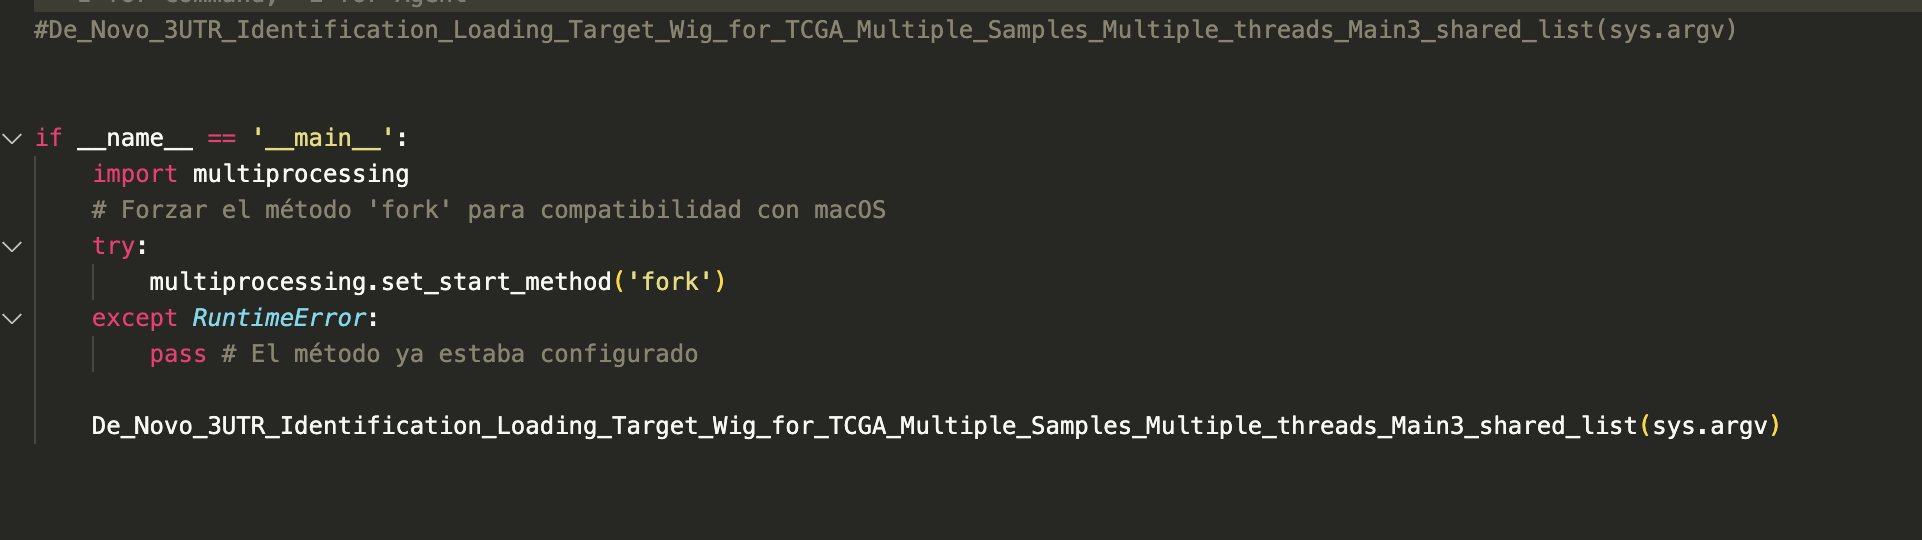

In [27]:
!python ../libs/DaPars2/src/DaPars2_Multi_Sample_Multi_Chr.py \
    ../assets/plos_2016/dapars2_run/dapars2_config.txt \
    ../assets/plos_2016/dapars2_run/chr_list.txt

3
[Sat Mar 21 15:23:33 2026] Start Analysis ...
../assets/plos_2016/dapars2_run/results_chr1
All samples Joint Processing chr1 ...
[Sat Mar 21 15:23:33 2026] Loading Coverage ...
../assets/plos_2016/bedgraph_sorted/D1.sorted.bedgraph
../assets/plos_2016/bedgraph_sorted/D3.sorted.bedgraph
../assets/plos_2016/bedgraph_sorted/M2.sorted.bedgraph
../assets/plos_2016/bedgraph_sorted/M3.sorted.bedgraph
../assets/plos_2016/bedgraph_sorted/D2.sorted.bedgraph
../assets/plos_2016/bedgraph_sorted/M1.sorted.bedgraph
[3240993401 3242392285 3243113317 3238184823 3236045847 3230715009]
[Sat Mar 21 15:23:34 2026] Loading Coverage Finished ...
#assigned events:
505
505
504
504
[Sat Mar 21 15:24:08 2026] Start Analysis ...
../assets/plos_2016/dapars2_run/results_chr10
All samples Joint Processing chr10 ...
[Sat Mar 21 15:24:08 2026] Loading Coverage ...
../assets/plos_2016/bedgraph_sorted/D1.sorted.bedgraph
../assets/plos_2016/bedgraph_sorted/D3.sorted.bedgraph
../assets/plos_2016/bedgraph_sorted/M2.sort

In [28]:
!cat ../assets/plos_2016/dapars2_run/results_chr15/M_vs_D_result_temp.chr15.txt

Gene	fit_value	Predicted_Proximal_APA	Loci	../assets/plos_2016/bedgraph_sorted/D1.sorted_PDUI	../assets/plos_2016/bedgraph_sorted/D2.sorted_PDUI	../assets/plos_2016/bedgraph_sorted/D3.sorted_PDUI	../assets/plos_2016/bedgraph_sorted/M1.sorted_PDUI	../assets/plos_2016/bedgraph_sorted/M2.sorted_PDUI	../assets/plos_2016/bedgraph_sorted/M3.sorted_PDUI
NIPA1	54.7	22825800	chr15:22823727-22829789	0.70	0.73	0.71	0.68	0.63	0.60
NIPA2	208.7	22867600	chr15:22866212-22869362	0.09	0.09	0.08	0.09	0.09	0.08
CYFIP1	111.3	22869500	chr15:22867051-22870192	0.09	0.09	0.09	0.10	0.12	0.09
TUBGCP5	5.1	22999500	chr15:22999176-22999866	0.43	0.78	0.56	0.66	0.52	0.51
SNRPN	170.7	24978557	chr15:24978406-24978723	0.10	0.12	0.12	0.11	0.12	0.11
UBE3A	62.4	25337950	chr15:25333727-25339257	0.12	0.14	0.11	0.12	0.12	0.13
ATP10A	2.1	25678900	chr15:25677272-25679974	NA	0.01	0.04	NA	NA	NA
GABRB3	368.2	26547650	chr15:26543551-26548134	0.64	0.70	0.64	0.66	0.66	0.61
GABRA5	77.4	26948200	chr15:26947933-26949208	0.71	0.76	0.67	

## Busco PML

In [38]:
!awk '$1=="chr15" && $3>=74044220 && $2<=74047827' ../assets/plos_2016/bedgraph_sorted/D*.sorted.bedgraph | sort -k4 -rn | head -n 20

chr15	74045250	74045300	6.800650119781494
chr15	74045300	74045350	6.460619926452637
chr15	74045650	74045700	6.1205902099609375
chr15	74045350	74045400	6.1205902099609375
chr15	74046500	74046550	6.115489959716797
chr15	74046200	74046250	5.860680103302002
chr15	74045100	74045150	5.780550003051758
chr15	74044500	74044600	5.780550003051758
chr15	74045450	74045500	5.751570224761963
chr15	74044500	74044600	5.605860233306885
chr15	74045700	74045800	5.4405198097229
chr15	74045550	74045600	5.4405198097229
chr15	74045150	74045250	5.4405198097229
chr15	74046250	74046300	5.351049900054932
chr15	74045600	74045650	5.351049900054932
chr15	74044450	74044500	5.351049900054932
chr15	74045500	74045550	5.244080066680908
chr15	74045350	74045400	5.244080066680908
chr15	74045600	74045650	5.100490093231201
chr15	74046150	74046200	5.096240043640137


In [41]:
!awk '$1=="chr15" && $2>=74044220 && $3<=74044320' ../assets/plos_2016/bedgraph_sorted/D*.sorted.bedgraph

chr15	74044250	74044300	3.5673699378967285


In [39]:
!grep -r "PML" ../assets/plos_2016/dapars2_run/results_chr*/ | head -n 3

In [171]:
base = f"{base_folder}/dapars2_run"
files = sorted(glob.glob(os.path.join(base, "results_chr*", "M_vs_D_result_temp.chr*.txt")))
print("Found:", len(files))
assert files, "No encontré result_temp.chr*.txt"

dfs = []
for f in files:
    df = pd.read_csv(f, sep="\t")
    df["source_file"] = os.path.basename(f)
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)
out_merged = f"{base_folder}/dapars2_run/NS5_vs_NS5_2xNLS_allchr.tsv"
all_df.to_csv(out_merged, sep="\t", index=False)
print("Wrote:", out_merged, "rows:", all_df.shape[0], "cols:", all_df.shape[1])

all_df.head(3)

Found: 24
Wrote: ../assets/plos_2016/dapars2_run/NS5_vs_NS5_2xNLS_allchr.tsv rows: 39776 cols: 11


,Gene,fit_value,Predicted_Proximal_APA,Loci,../assets/plos_2016/bedgraph_sorted/D1.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/D2.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/D3.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/M1.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/M2.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/M3.sorted_PDUI,source_file
0,ENSG00000187634.13|ENST00000616016.5,634.6,944058,chr1:943907-944574,1.0,1.0,1.0,1.0,1.0,1.0,M_vs_D_result_temp.chr1.txt
1,ENSG00000187634.13|ENST00000618323.5,634.6,944058,chr1:943907-944574,1.0,1.0,1.0,1.0,1.0,1.0,M_vs_D_result_temp.chr1.txt
2,ENSG00000187634.13|ENST00000342066.8,634.6,944058,chr1:943907-944574,1.0,1.0,1.0,1.0,1.0,1.0,M_vs_D_result_temp.chr1.txt


In [172]:
all_df[all_df['Gene'].str.contains('ENSG00000140464', case=False, na=False)]


,Gene,fit_value,Predicted_Proximal_APA,Loci,../assets/plos_2016/bedgraph_sorted/D1.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/D2.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/D3.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/M1.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/M2.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/M3.sorted_PDUI,source_file
12821,ENSG00000140464.20|ENST00000395135.7,0.4,74043150,chr15:74042988-74043337,0.34,NaN,0.23,NaN,0.44,NaN,M_vs_D_result_temp.chr15.txt
12822,ENSG00000140464.20|ENST00000268059.10,3.8,74035650,chr15:74035171-74036394,0.50,1.00,1.00,0.85,NaN,NaN,M_vs_D_result_temp.chr15.txt
12823,ENSG00000140464.20|ENST00000354026.10,3.8,74035650,chr15:74035171-74036394,0.50,1.00,1.00,0.85,NaN,NaN,M_vs_D_result_temp.chr15.txt
12824,ENSG00000140464.20|ENST00000569477.5,2.6,74035350,chr15:74035131-74035590,0.78,0.41,0.58,NaN,NaN,NaN,M_vs_D_result_temp.chr15.txt
12825,ENSG00000140464.20|ENST00000569965.5,0.4,74043150,chr15:74042988-74043338,0.34,NaN,0.23,NaN,0.44,NaN,M_vs_D_result_temp.chr15.txt
12826,ENSG00000140464.20|ENST00000436891.7,3.8,74035650,chr15:74035171-74036394,0.50,1.00,1.00,0.85,NaN,NaN,M_vs_D_result_temp.chr15.txt
12827,ENSG00000140464.20|ENST00000435786.6,8.9,74034628,chr15:74034477-74036394,1.00,0.80,0.67,NaN,0.80,NaN,M_vs_D_result_temp.chr15.txt
12828,ENSG00000140464.20|ENST00000564428.5,0.4,74043150,chr15:74042988-74043338,0.34,NaN,0.23,NaN,0.44,NaN,M_vs_D_result_temp.chr15.txt
12829,ENSG00000140464.20|ENST00000359928.8,0.4,74043150,chr15:74042988-74043338,0.34,NaN,0.23,NaN,0.44,NaN,M_vs_D_result_temp.chr15.txt
12830,ENSG00000140464.20|ENST00000563500.5,9.0,74033450,chr15:74033155-74036393,0.27,0.18,0.13,0.23,0.16,0.28,M_vs_D_result_temp.chr15.txt


In [173]:
ctrl_keys  = ["M1", "M2", "M3"]
treat_keys = ["D1", "D2", "D3"]

# columnas PDUI (son las que arrancan con /content/bedgraph_sorted/...)
pdui_cols = [c for c in all_df.columns if c.endswith("_PDUI")]

def pick_cols(keys):
    cols = []
    for c in pdui_cols:
        if any(k in c for k in keys):
            cols.append(c)
    return cols

ctrl_cols  = pick_cols(ctrl_keys)
treat_cols = pick_cols(treat_keys)

print("CTRL cols:", len(ctrl_cols), ctrl_cols[:2])
print("TREAT cols:", len(treat_cols), treat_cols[:2])
assert len(ctrl_cols)==3 and len(treat_cols)==3, "No pude identificar 3+3 columnas PDUI"

res = all_df.copy()

# stats básicos
res["mean_CTRL"]  = res[ctrl_cols].mean(axis=1)
res["mean_TREAT"] = res[treat_cols].mean(axis=1)
res["delta_PDUI"] = res["mean_TREAT"] - res["mean_CTRL"]
res["abs_delta"]  = res["delta_PDUI"].abs()

# colapsar a nivel gene_id (opcional): quedate con el transcripto con mayor |Δ|
res["gene_id"] = res["Gene"].str.split("|").str[0]
res_gene = (res.sort_values("abs_delta", ascending=False)
              .groupby("gene_id", as_index=False)
              .head(1)
              .reset_index(drop=True))

top10 = res_gene.sort_values("abs_delta", ascending=False).head(10)
top10[["gene_id","Gene","Loci","Predicted_Proximal_APA","mean_CTRL","mean_TREAT","delta_PDUI"]]

CTRL cols: 3 ['../assets/plos_2016/bedgraph_sorted/M1.sorted_PDUI', '../assets/plos_2016/bedgraph_sorted/M2.sorted_PDUI']
TREAT cols: 3 ['../assets/plos_2016/bedgraph_sorted/D1.sorted_PDUI', '../assets/plos_2016/bedgraph_sorted/D2.sorted_PDUI']


,gene_id,Gene,Loci,Predicted_Proximal_APA,mean_CTRL,mean_TREAT,delta_PDUI
0,ENSG00000180071.21,ENSG00000180071.21|ENST00000602295.5,chr9:38571357-38573129,38571900,0.890,0.120000,-0.770000
1,ENSG00000254206.6,ENSG00000254206.6|ENST00000614927.1,chr16:29385033-29385685,29385534,0.855,0.223333,-0.631667
2,ENSG00000163617.11,ENSG00000163617.11|ENST00000491000.5,chr3:114005507-114005962,114005750,1.000,0.370000,-0.630000
4,ENSG00000119487.17,ENSG00000119487.17|ENST00000394060.7,chr9:125521467-125521765,125521600,0.260,0.850000,0.590000
3,ENSG00000124508.17,ENSG00000124508.17|ENST00000490025.5,chr6:26392374-26392722,26392525,0.370,0.960000,0.590000
5,ENSG00000166359.11,ENSG00000166359.11|ENST00000361680.6,chr19:33175395-33175795,33175546,0.860,0.280000,-0.580000
6,ENSG00000181004.10,ENSG00000181004.10|ENST00000433287.1,chr4:122741882-122742465,122742150,1.000,0.430000,-0.570000
7,ENSG00000079385.23,ENSG00000079385.23|ENST00000403444.7,chr19:42507313-42509228,42509077,0.120,0.676667,0.556667
8,ENSG00000171105.14,ENSG00000171105.14|ENST00000302850.10,chr19:7112264-7117410,7117050,0.350,0.900000,0.550000
9,ENSG00000122507.21,ENSG00000122507.21|ENST00000434373.3,chr7:33604864-33605626,33605015,0.260,0.810000,0.550000


In [174]:
warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*Precision loss occurred in moment calculation.*")

def welch_p(row):
    # Extraemos valores ignorando los NaNs internos de cada grupo
    a = row[ctrl_cols].astype(float).dropna().values
    b = row[treat_cols].astype(float).dropna().values
    
    # Exigimos al menos 2 réplicas válidas por grupo para tener rigor
    if len(a) < 2 or len(b) < 2:
        return np.nan
        
    # Evitamos error si la varianza es cero
    if np.var(a) == 0 and np.var(b) == 0:
        return np.nan
        
    # Calculamos el p-value
    return ttest_ind(a, b, equal_var=False, nan_policy='omit').pvalue
res_gene["p_welch"] = res_gene.apply(welch_p, axis=1)
top10 = res_gene.sort_values("abs_delta", ascending=False).head(10)
top10[["gene_id","Gene","Loci","mean_CTRL","mean_TREAT","delta_PDUI","p_welch"]]


,gene_id,Gene,Loci,mean_CTRL,mean_TREAT,delta_PDUI,p_welch
0,ENSG00000180071.21,ENSG00000180071.21|ENST00000602295.5,chr9:38571357-38573129,0.890,0.120000,-0.770000,NaN
1,ENSG00000254206.6,ENSG00000254206.6|ENST00000614927.1,chr16:29385033-29385685,0.855,0.223333,-0.631667,0.135998
2,ENSG00000163617.11,ENSG00000163617.11|ENST00000491000.5,chr3:114005507-114005962,1.000,0.370000,-0.630000,NaN
4,ENSG00000119487.17,ENSG00000119487.17|ENST00000394060.7,chr9:125521467-125521765,0.260,0.850000,0.590000,NaN
3,ENSG00000124508.17,ENSG00000124508.17|ENST00000490025.5,chr6:26392374-26392722,0.370,0.960000,0.590000,NaN
5,ENSG00000166359.11,ENSG00000166359.11|ENST00000361680.6,chr19:33175395-33175795,0.860,0.280000,-0.580000,NaN
6,ENSG00000181004.10,ENSG00000181004.10|ENST00000433287.1,chr4:122741882-122742465,1.000,0.430000,-0.570000,NaN
7,ENSG00000079385.23,ENSG00000079385.23|ENST00000403444.7,chr19:42507313-42509228,0.120,0.676667,0.556667,NaN
8,ENSG00000171105.14,ENSG00000171105.14|ENST00000302850.10,chr19:7112264-7117410,0.350,0.900000,0.550000,NaN
9,ENSG00000122507.21,ENSG00000122507.21|ENST00000434373.3,chr7:33604864-33605626,0.260,0.810000,0.550000,NaN


In [175]:
res.columns

Index(['Gene', 'fit_value', 'Predicted_Proximal_APA', 'Loci',
       '../assets/plos_2016/bedgraph_sorted/D1.sorted_PDUI',
       '../assets/plos_2016/bedgraph_sorted/D2.sorted_PDUI',
       '../assets/plos_2016/bedgraph_sorted/D3.sorted_PDUI',
       '../assets/plos_2016/bedgraph_sorted/M1.sorted_PDUI',
       '../assets/plos_2016/bedgraph_sorted/M2.sorted_PDUI',
       '../assets/plos_2016/bedgraph_sorted/M3.sorted_PDUI', 'source_file',
       'mean_CTRL', 'mean_TREAT', 'delta_PDUI', 'abs_delta', 'gene_id'],
      dtype='object')

In [176]:
# Inicializamos la columna FDR y calculamos la corrección Benjamini-Hochberg
res_gene["FDR"] = np.nan
valid_mask = res_gene["p_welch"].notna()
res_gene.loc[valid_mask, "FDR"] = multipletests(res_gene.loc[valid_mask, "p_welch"], method='fdr_bh')[1]


# Filtramos solo los genes donde pudimos calcular estadística
df_plot = res_gene.dropna(subset=['FDR', 'delta_PDUI']).copy()

# Calculamos el -log10 del FDR para el eje Y del Volcano Plot
# Sumamos un epsilon (1e-300) para evitar log(0) si hay p-values extremadamente bajos
df_plot['-log10(FDR)'] = -np.log10(df_plot['FDR'] + 1e-300)

Total de genes (p < 0.05 y |Delta| > 0.20): 92
Balance: (array(['Acortados (-)', 'Alargados (+)'], dtype='<U13'), array([41, 51]))


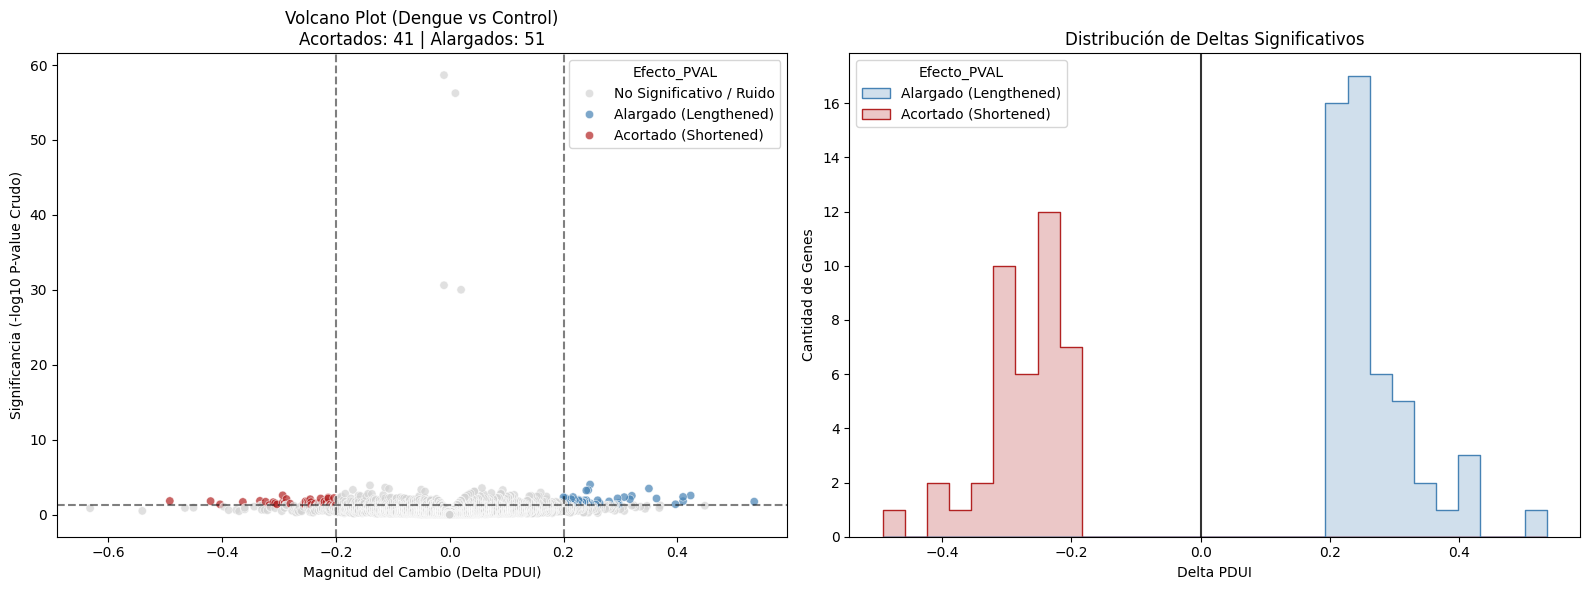

In [177]:
# 1. Ajustamos los umbrales (Usamos el p-value crudo en vez del FDR)
PVAL_CUTOFF = 0.05
DELTA_CUTOFF = 0.20 

# 2. Exploración rápida
genes_reales = df_plot[(df_plot['p_welch'] < PVAL_CUTOFF) & (df_plot['delta_PDUI'].abs() >= DELTA_CUTOFF)].copy()
print(f"Total de genes (p < 0.05 y |Delta| > 0.20): {len(genes_reales)}")

conteo = np.where(genes_reales['delta_PDUI'] < 0, 'Acortados (-)', 'Alargados (+)')
print("Balance:", np.unique(conteo, return_counts=True))


# Recalculamos el eje Y para que use p_welch
df_plot['-log10(PVAL)'] = -np.log10(df_plot['p_welch'] + 1e-300)

def classify_event_pval(row):
    if row['p_welch'] < PVAL_CUTOFF:
        if row['delta_PDUI'] <= -DELTA_CUTOFF:
            return 'Acortado (Shortened)'
        elif row['delta_PDUI'] >= DELTA_CUTOFF:
            return 'Alargado (Lengthened)'
    return 'No Significativo / Ruido'

df_plot['Efecto_PVAL'] = df_plot.apply(classify_event_pval, axis=1)

n_short = (df_plot['Efecto_PVAL'] == 'Acortado (Shortened)').sum()
n_long = (df_plot['Efecto_PVAL'] == 'Alargado (Lengthened)').sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colores = {'Acortado (Shortened)': 'firebrick', 'Alargado (Lengthened)': 'steelblue', 'No Significativo / Ruido': 'lightgray'}

# --- GRÁFICO 1: VOLCANO PLOT ---
sns.scatterplot(data=df_plot, x='delta_PDUI', y='-log10(PVAL)', hue='Efecto_PVAL', palette=colores, alpha=0.7, ax=ax1)
ax1.axhline(-np.log10(PVAL_CUTOFF), ls='--', color='black', alpha=0.5)
ax1.axvline(-DELTA_CUTOFF, ls='--', color='black', alpha=0.5)
ax1.axvline(DELTA_CUTOFF, ls='--', color='black', alpha=0.5)
ax1.set_title(f'Volcano Plot (Dengue vs Control)\nAcortados: {n_short} | Alargados: {n_long}')
ax1.set_xlabel('Magnitud del Cambio (Delta PDUI)')
ax1.set_ylabel('Significancia (-log10 P-value Crudo)')

# --- GRÁFICO 2: HISTOGRAMA ---
df_sig = df_plot[df_plot['Efecto_PVAL'] != 'No Significativo / Ruido']

if len(df_sig) > 0:
    sns.histplot(data=df_sig, x='delta_PDUI', hue='Efecto_PVAL', palette=colores, element="step", common_norm=False, bins=30, ax=ax2)
else:
    ax2.text(0.5, 0.5, '0 genes superaron el filtro', ha='center', va='center', fontsize=12, color='firebrick', transform=ax2.transAxes)

ax2.axvline(0, ls='-', color='black', alpha=0.8)
ax2.set_title('Distribución de Deltas Significativos')
ax2.set_xlabel('Delta PDUI')
ax2.set_ylabel('Cantidad de Genes')

plt.tight_layout()
plt.show()

## Visualizaciones

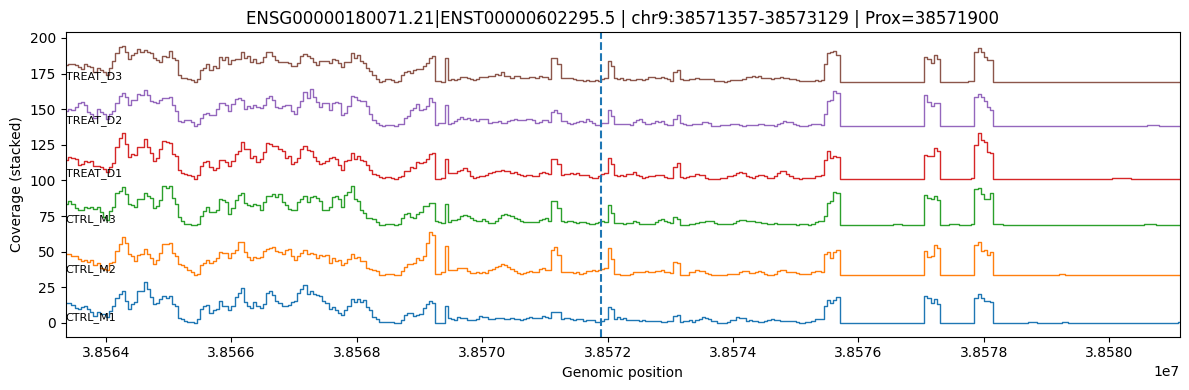

In [178]:
bg_map = {
  "CTRL_M1": f"{base_folder}/bedgraph_sorted/M1.sorted.bedgraph",
  "CTRL_M2": f"{base_folder}/bedgraph_sorted/M2.sorted.bedgraph",
  "CTRL_M3": f"{base_folder}/bedgraph_sorted/M3.sorted.bedgraph",
  "TREAT_D1":f"{base_folder}/bedgraph_sorted/D1.sorted.bedgraph",
  "TREAT_D2":f"{base_folder}/bedgraph_sorted/D2.sorted.bedgraph",
  "TREAT_D3":f"{base_folder}/bedgraph_sorted/D3.sorted.bedgraph",
}

def parse_loci(loci_str):
    # ejemplo: chr1:1785284-1787053
    chrom, rest = loci_str.split(":")
    s, e = rest.split("-")
    return chrom, int(s), int(e)

def load_bedgraph_region(path, chrom, start, end):
    # lee linealmente; para región chica funciona bien en Colab
    xs = []
    with open(path) as f:
        for line in f:
            c, s, e, v = line.rstrip("\n").split("\t")
            if c != chrom:
                continue
            s = int(s); e = int(e); v = float(v)
            if e < start:
                continue
            if s > end:
                break
            # clip al intervalo solicitado
            s2 = max(s, start)
            e2 = min(e, end)
            xs.append((s2, e2, v))
    return xs

def plot_tracks(gene_label, loci, prox_site, flank=5000, out_png=None):
    chrom, s, e = parse_loci(loci)
    s0 = max(0, s - flank)
    e0 = e + flank

    fig, ax = plt.subplots(figsize=(12, 4))
    y_offset = 0.0

    for name, path in bg_map.items():
        segs = load_bedgraph_region(path, chrom, s0, e0)
        # construir serie escalonada
        X, Y = [], []
        for a,b,v in segs:
            X += [a, b]
            Y += [v, v]
        # shift para apilar tracks (sencillo y legible)
        ax.plot(X, [yy + y_offset for yy in Y], linewidth=1)
        ax.text(s0, y_offset, name, va="bottom", fontsize=8)
        y_offset += (max(Y) if Y else 1.0) + 5

    ax.axvline(int(prox_site), linestyle="--")
    ax.set_title(f"{gene_label} | {loci} | Prox={prox_site}")
    ax.set_xlabel("Genomic position")
    ax.set_ylabel("Coverage (stacked)")
    ax.set_xlim(s0, e0)

    plt.tight_layout()
    if out_png:
        plt.savefig(out_png, dpi=150)
    plt.show()

# plot top1 como prueba
r = top10.iloc[0]
plot_tracks(r["Gene"], r["Loci"], r["Predicted_Proximal_APA"], flank=8000)


## Plot PML

In [179]:
PML_reads = res_gene[res_gene['Gene'].str.contains('ENSG00000140464', case=False, na=False)]#.sort_values("abs_delta", ascending=False).head(10)
# for i, r in PML_reads.reset_index(drop=True).iterrows():
#     out = f"{base_folder}/stack/top{i+1}_{r['gene_id']}.png"
#     plot_tracks(r["Gene"], r["Loci"], r["Predicted_Proximal_APA"], flank=8000, out_png=out)
#     print("saved:", out)
PML_reads

,Gene,fit_value,Predicted_Proximal_APA,Loci,../assets/plos_2016/bedgraph_sorted/D1.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/D2.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/D3.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/M1.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/M2.sorted_PDUI,../assets/plos_2016/bedgraph_sorted/M3.sorted_PDUI,source_file,mean_CTRL,mean_TREAT,delta_PDUI,abs_delta,gene_id,p_welch,FDR
978,ENSG00000140464.20|ENST00000359928.8,0.4,74043150,chr15:74042988-74043338,0.34,NaN,0.23,NaN,0.44,NaN,M_vs_D_result_temp.chr15.txt,0.44,0.285,-0.155,0.155,ENSG00000140464.20,NaN,NaN


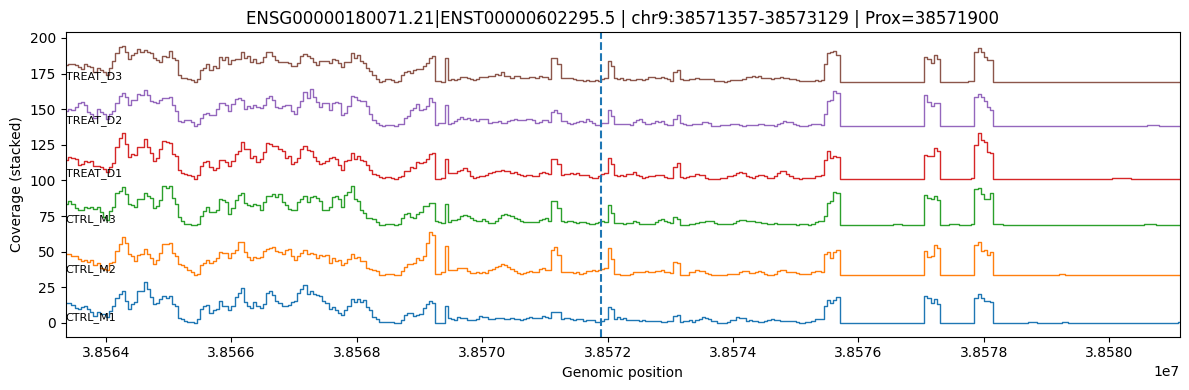

saved: ../assets/plos_2016/stack/top1_ENSG00000180071.21.png


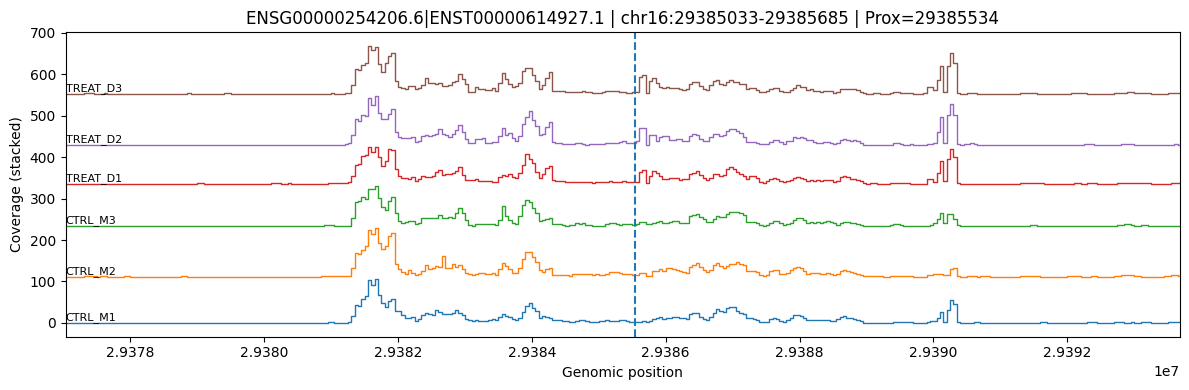

saved: ../assets/plos_2016/stack/top2_ENSG00000254206.6.png


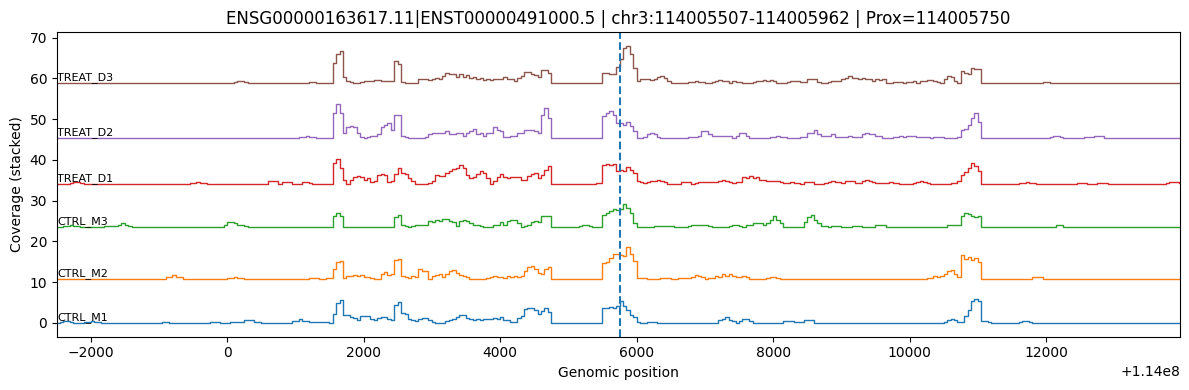

saved: ../assets/plos_2016/stack/top3_ENSG00000163617.11.png


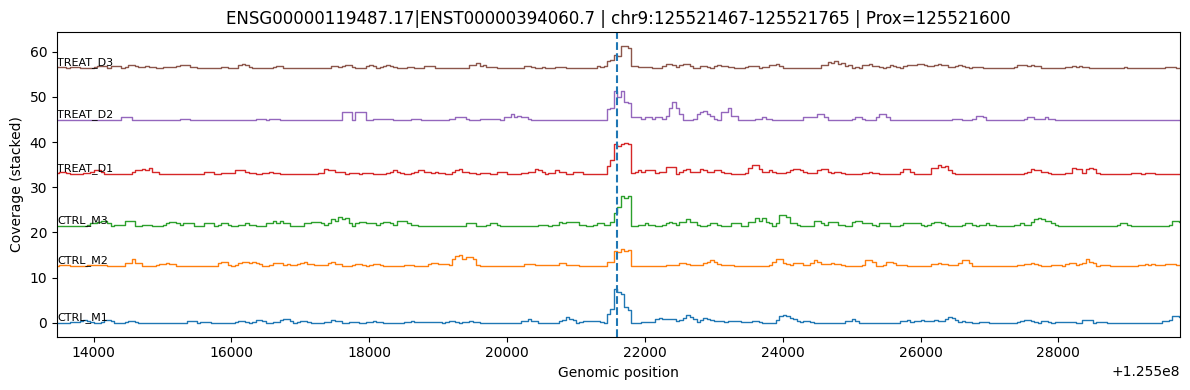

saved: ../assets/plos_2016/stack/top4_ENSG00000119487.17.png


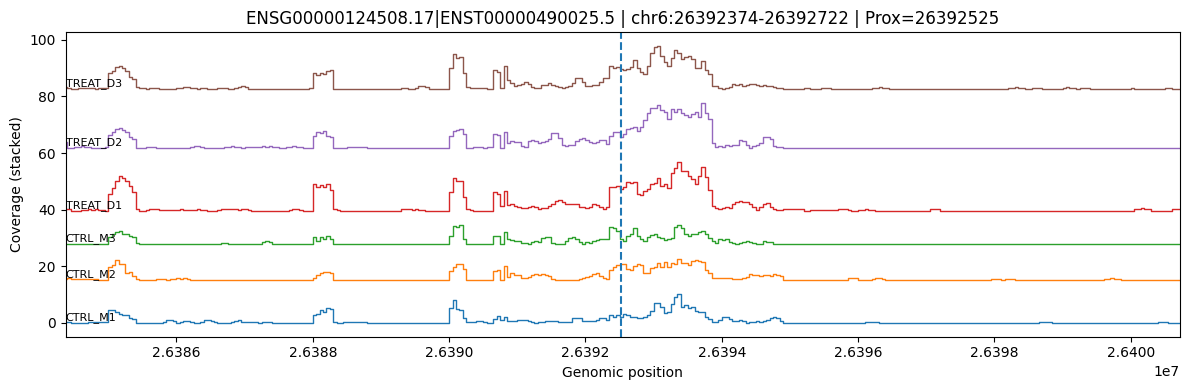

saved: ../assets/plos_2016/stack/top5_ENSG00000124508.17.png


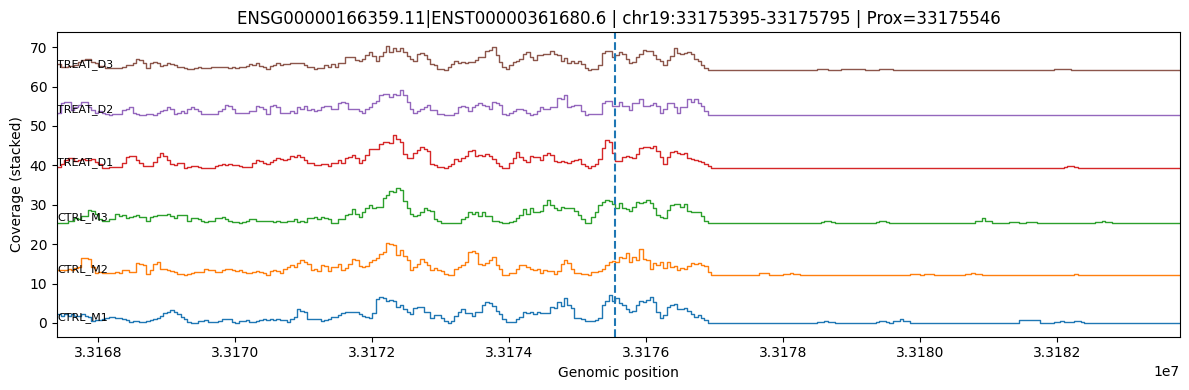

saved: ../assets/plos_2016/stack/top6_ENSG00000166359.11.png


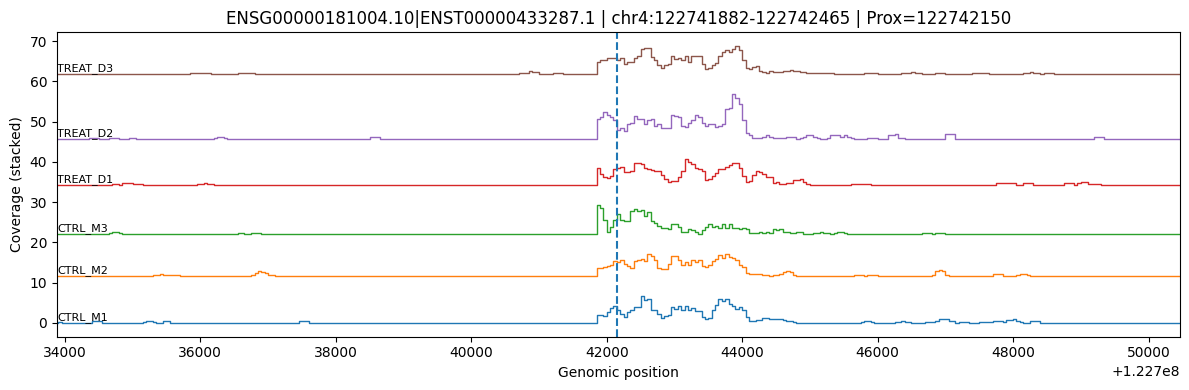

saved: ../assets/plos_2016/stack/top7_ENSG00000181004.10.png


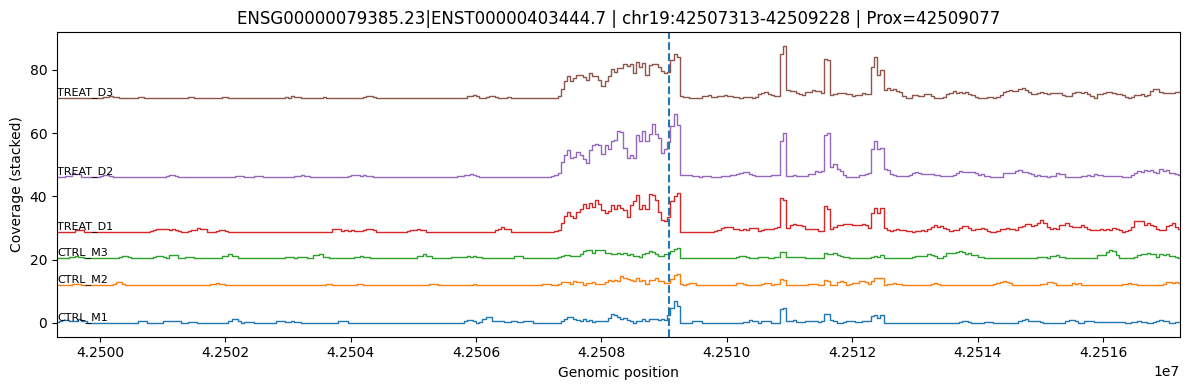

saved: ../assets/plos_2016/stack/top8_ENSG00000079385.23.png


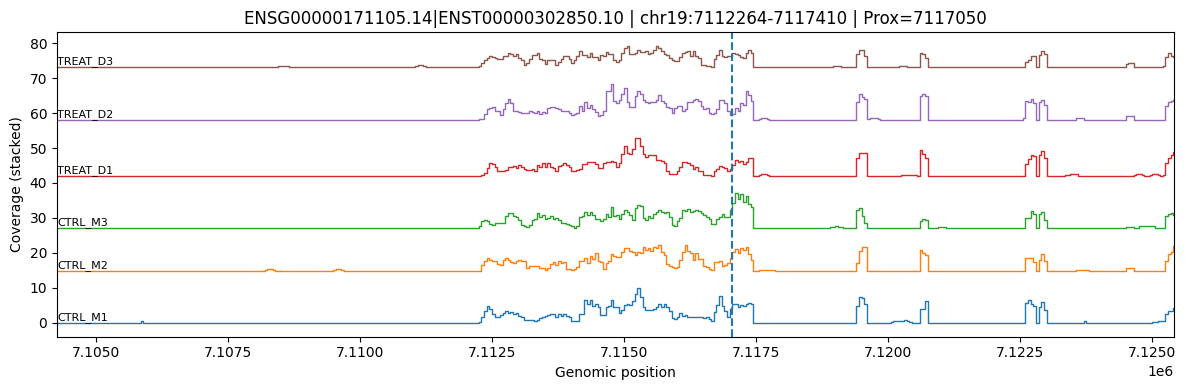

saved: ../assets/plos_2016/stack/top9_ENSG00000171105.14.png


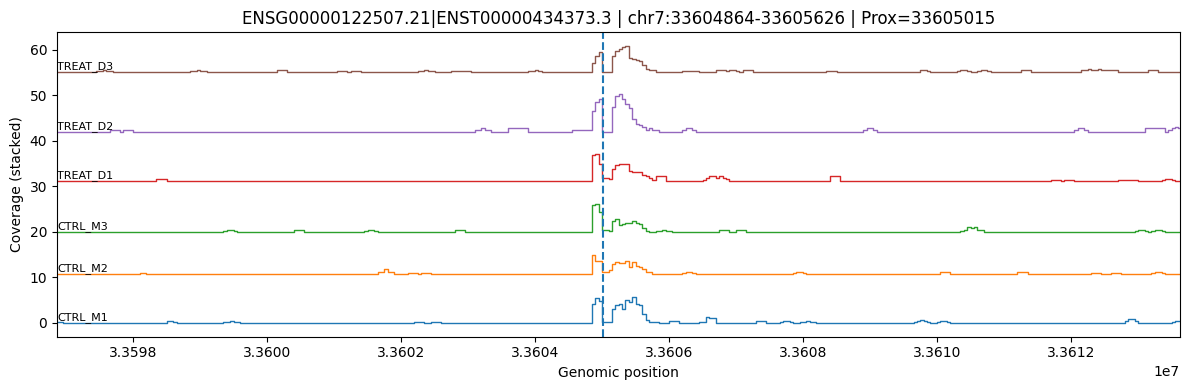

saved: ../assets/plos_2016/stack/top10_ENSG00000122507.21.png


In [180]:
for i, r in top10.reset_index(drop=True).iterrows():
    out = f"{base_folder}/stack/top{i+1}_{r['gene_id']}.png"
    plot_tracks(r["Gene"], r["Loci"], r["Predicted_Proximal_APA"], flank=8000, out_png=out)
    print("saved:", out)


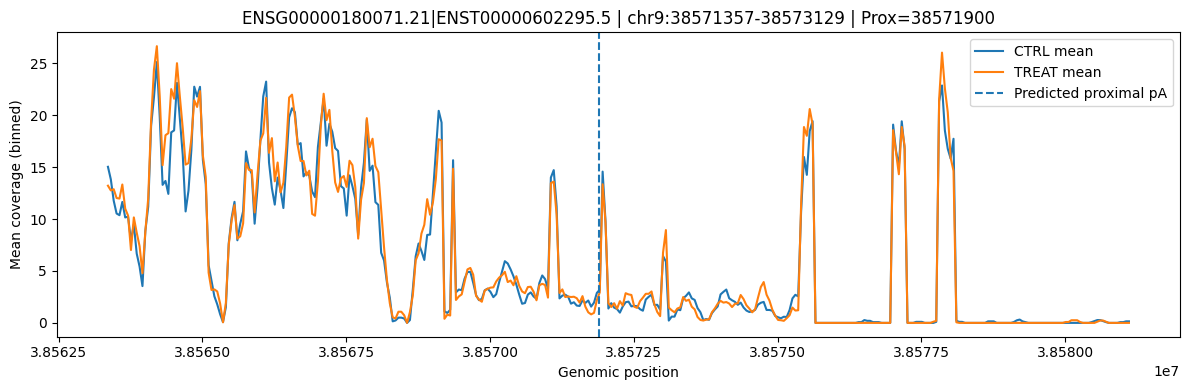

In [181]:
import numpy as np
import matplotlib.pyplot as plt

ctrl_paths = [
    f"{base_folder}/bedgraph_sorted/M1.sorted.bedgraph",
    f"{base_folder}/bedgraph_sorted/M2.sorted.bedgraph",
    f"{base_folder}/bedgraph_sorted/M3.sorted.bedgraph"
]
treat_paths = [
    f"{base_folder}/bedgraph_sorted/D1.sorted.bedgraph",
    f"{base_folder}/bedgraph_sorted/D2.sorted.bedgraph",
    f"{base_folder}/bedgraph_sorted/D3.sorted.bedgraph",
]

def parse_loci(loci_str):
    chrom, rest = loci_str.split(":")
    s, e = rest.split("-")
    return chrom, int(s), int(e)

def load_bedgraph_region(path, chrom, start, end):
    segs = []
    with open(path) as f:
        for line in f:
            c, s, e, v = line.rstrip("\n").split("\t")
            if c != chrom:
                continue
            s = int(s); e = int(e); v = float(v)
            if e < start:
                continue
            if s > end:
                break
            segs.append((max(s, start), min(e, end), v))
    return segs

def segs_to_bins(segs, start, end, step=50):
    """Convierte segmentos bedgraph a vector binned (mean coverage por bin)."""
    n = int(np.ceil((end - start) / step))
    y = np.zeros(n, dtype=float)
    # para cada segmento, rellenar bins intersectados
    for s, e, v in segs:
        b0 = max(0, (s - start) // step)
        b1 = min(n, int(np.ceil((e - start) / step)))
        y[b0:b1] = v
    x = start + np.arange(n) * step
    return x, y

def mean_track(paths, chrom, start, end, step=50):
    ys = []
    x_ref = None
    for p in paths:
        segs = load_bedgraph_region(p, chrom, start, end)
        x, y = segs_to_bins(segs, start, end, step=step)
        if x_ref is None:
            x_ref = x
        ys.append(y)
    return x_ref, np.mean(np.vstack(ys), axis=0)

def plot_mean_ctrl_vs_treat(gene_label, loci, prox_site, flank=8000, step=50, out_png=None):
    chrom, s, e = parse_loci(loci)
    s0 = max(0, s - flank)
    e0 = e + flank

    x, y_ctrl  = mean_track(ctrl_paths,  chrom, s0, e0, step=step)
    _, y_treat = mean_track(treat_paths, chrom, s0, e0, step=step)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x, y_ctrl,  label="CTRL mean")
    ax.plot(x, y_treat, label="TREAT mean")
    ax.axvline(int(prox_site), linestyle="--", label="Predicted proximal pA")

    ax.set_title(f"{gene_label} | {loci} | Prox={prox_site}")
    ax.set_xlabel("Genomic position")
    ax.set_ylabel("Mean coverage (binned)")
    ax.legend()
    plt.tight_layout()

    if out_png:
        plt.savefig(out_png, dpi=150)
    plt.show()

# ejemplo con el top1 que ya tenías calculado
r = top10.iloc[0]
plot_mean_ctrl_vs_treat(r["Gene"], r["Loci"], r["Predicted_Proximal_APA"], flank=8000, step=50)


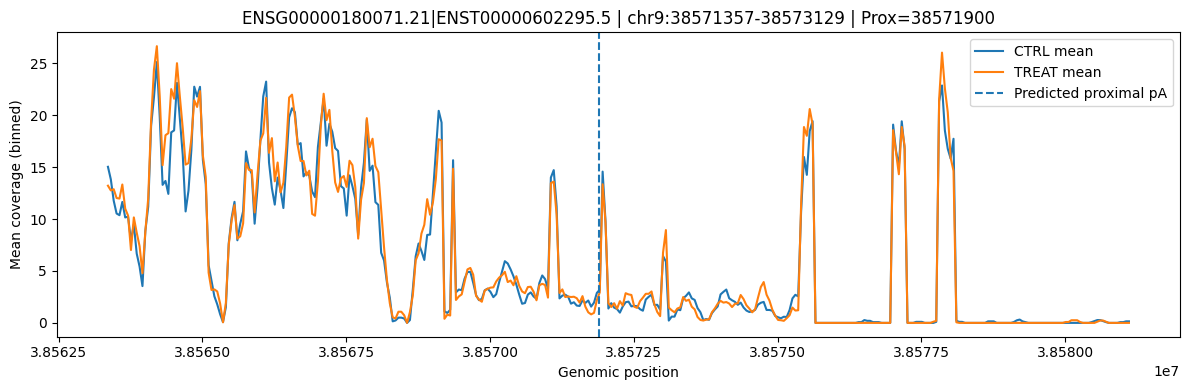

saved: ../assets/plos_2016/mean_track/top1_ENSG00000180071.21_meanCTRLvsTREAT.png


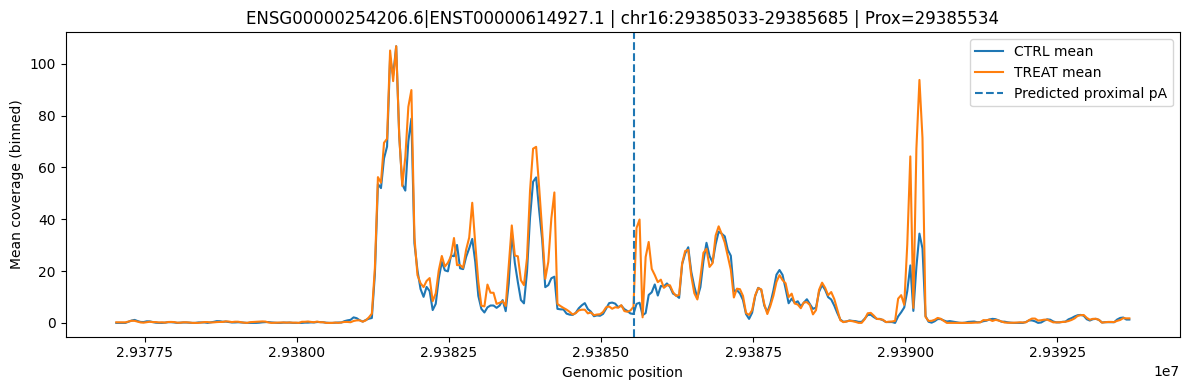

saved: ../assets/plos_2016/mean_track/top2_ENSG00000254206.6_meanCTRLvsTREAT.png


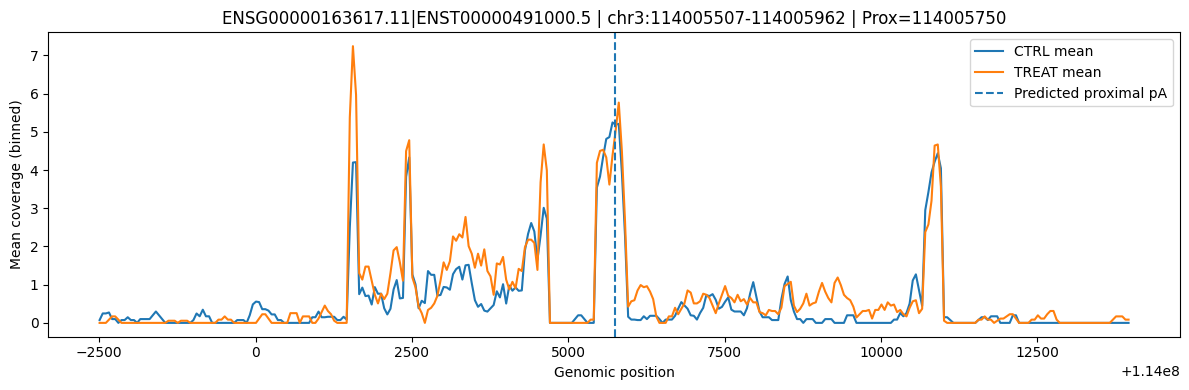

saved: ../assets/plos_2016/mean_track/top3_ENSG00000163617.11_meanCTRLvsTREAT.png


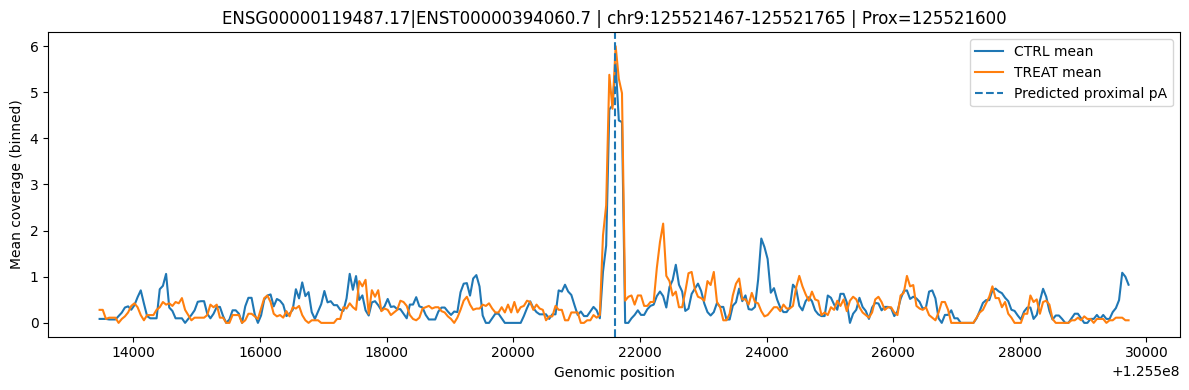

saved: ../assets/plos_2016/mean_track/top4_ENSG00000119487.17_meanCTRLvsTREAT.png


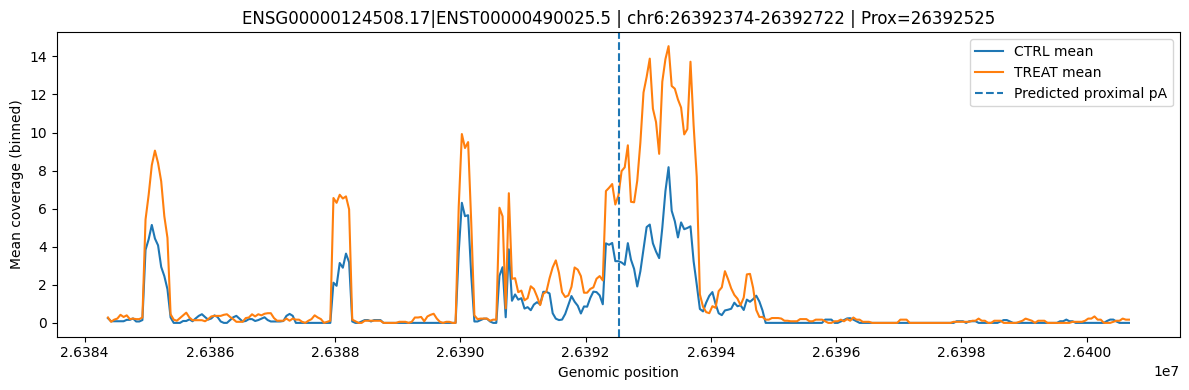

saved: ../assets/plos_2016/mean_track/top5_ENSG00000124508.17_meanCTRLvsTREAT.png


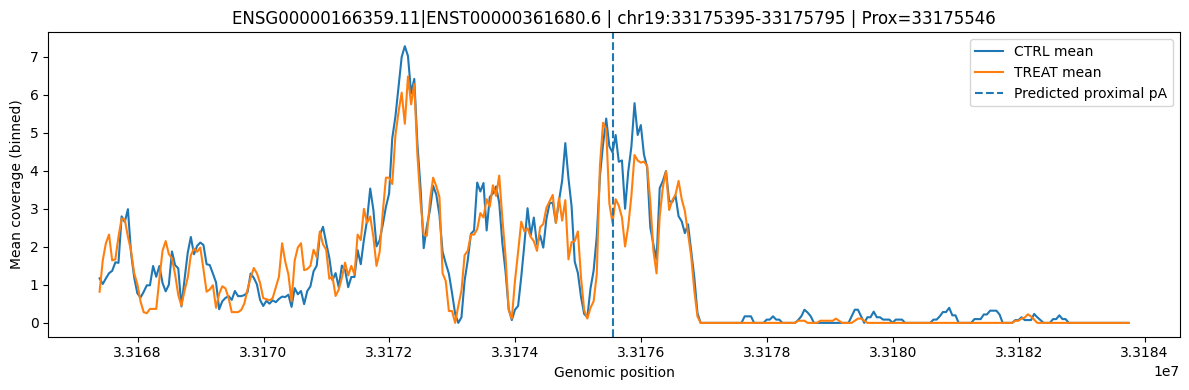

saved: ../assets/plos_2016/mean_track/top6_ENSG00000166359.11_meanCTRLvsTREAT.png


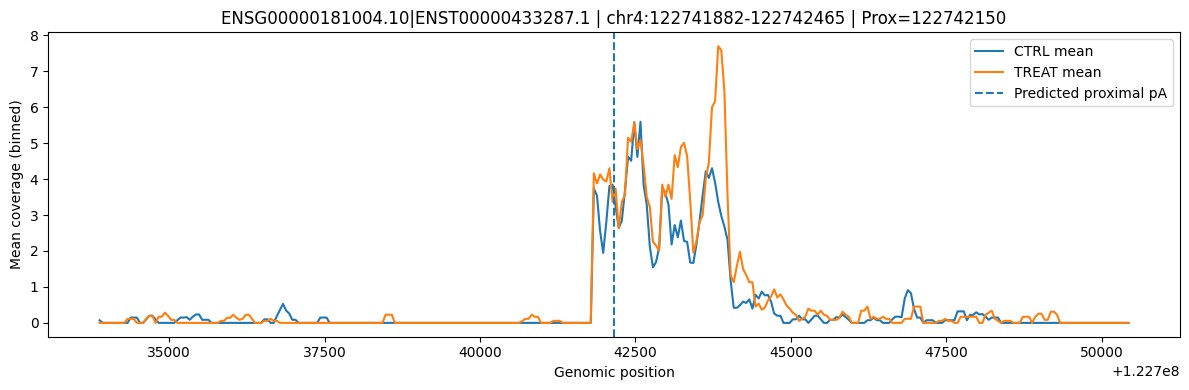

saved: ../assets/plos_2016/mean_track/top7_ENSG00000181004.10_meanCTRLvsTREAT.png


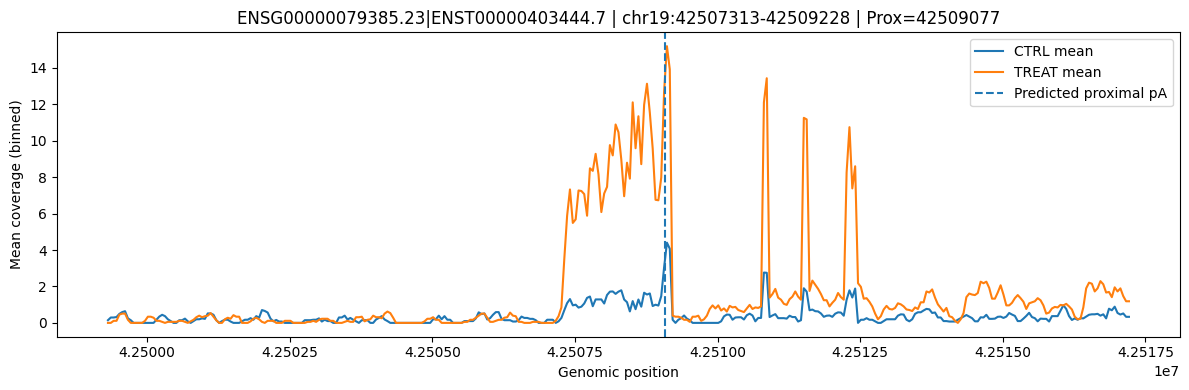

saved: ../assets/plos_2016/mean_track/top8_ENSG00000079385.23_meanCTRLvsTREAT.png


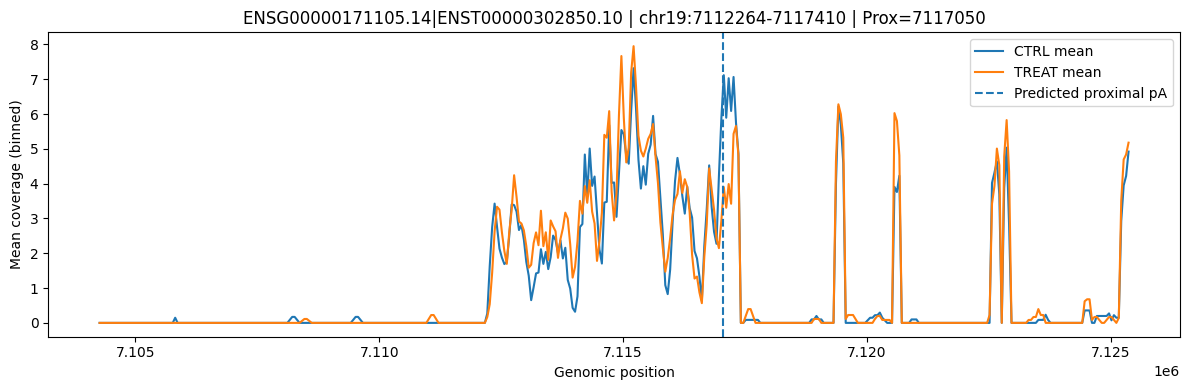

saved: ../assets/plos_2016/mean_track/top9_ENSG00000171105.14_meanCTRLvsTREAT.png


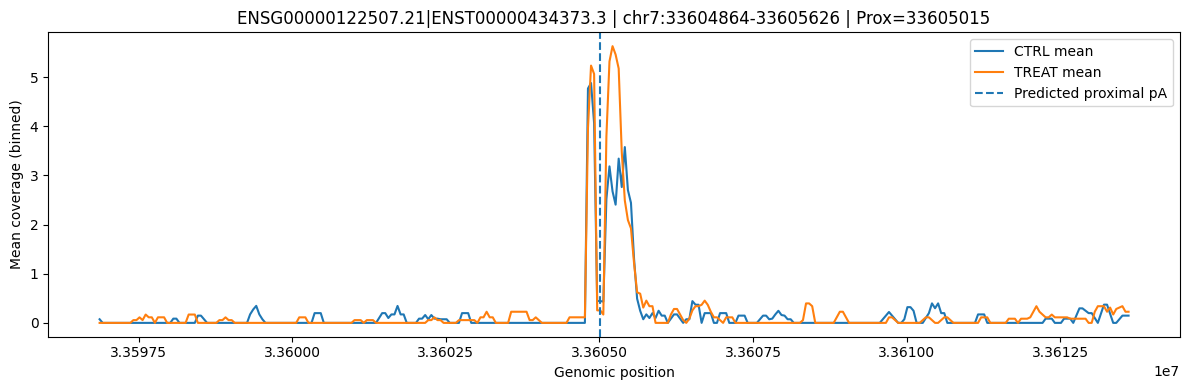

saved: ../assets/plos_2016/mean_track/top10_ENSG00000122507.21_meanCTRLvsTREAT.png


In [182]:
for i, r in top10.reset_index(drop=True).iterrows():
    out = f"{base_folder}/mean_track/top{i+1}_{r['gene_id']}_meanCTRLvsTREAT.png"
    plot_mean_ctrl_vs_treat(r["Gene"], r["Loci"], r["Predicted_Proximal_APA"], flank=8000, step=50, out_png=out)
    print("saved:", out)


## Guardamos resultados

In [183]:
out_root = f"{base_folder}/DaPars2_M_vs_D"

subdirs = [
    "tables",
    "figures",
    "per_chromosome",
    "config",
    "logs"
]

for sd in subdirs:
    Path(f"{out_root}/{sd}").mkdir(parents=True, exist_ok=True)

print("Created:", out_root)

src_base = f"{base_folder}/dapars2_run"

for d in glob.glob(f"{src_base}/results_chr*"):
    dest = f"{out_root}/per_chromosome/{os.path.basename(d)}"
    if os.path.exists(dest):
        shutil.rmtree(dest)
    shutil.copytree(d, dest)

print("Per-chromosome results copied")


# merged all chromosomes
shutil.copy(
    f"{base_folder}/dapars2_run/NS5_vs_NS5_2xNLS_allchr.tsv",
    f"{out_root}/tables/NS5_vs_NS5_2xNLS_allchr.tsv"
)

# top10 ranking
top10_out = f"{out_root}/tables/NS5_vs_NS5_2xNLS_top10_deltaPDUI.tsv"
top10.to_csv(top10_out, sep="\t", index=False)

print("Tables copied")


for fig in glob.glob(f"{base_folder}/top*_meanCTRLvsTREAT.png"):
    shutil.copy(fig, f"{out_root}/figures/{os.path.basename(fig)}")

print("Figures copied")


shutil.copy(
    f"{base_folder}/dapars2_run/dapars2_config.txt",
    f"{out_root}/config/dapars2_config.txt"
)

shutil.copy(
    f"{base_folder}/utr3/hg38_3UTR_annotation.bed",
    f"{out_root}/config/hg38_3UTR_annotation.bed"
)

shutil.copy(
    f"{base_folder}/dapars2_run/chr_list.txt",
    f"{out_root}/config/chr_list.txt"
)

print("Config & annotation copied")

# shutil.copytree(
#     f"{base_folder}/dapars2_run/logs",
#     f"{out_root}/logs",
#     dirs_exist_ok=True
# )

# print("Logs copied")


readme = """\
DaPars2 analysis – NS5 vs NS5 2xNLS (Dengue)

Location:
StartUp/Labo Topografia Transcriptomica/Dengue/DaPars2_NS5_vs_NS5_2xNLS

Genome: hg38 (GRCh38)
Input: bigWig → bedGraph (bamCoverage)
Tool: DaPars2 (multi-chromosome mode)

Folders:
- tables/: merged results and top hits (ΔPDUI)
- figures/: coverage plots (CTRL mean vs TREAT mean)
- per_chromosome/: raw DaPars2 outputs by chromosome
- config/: config, 3'UTR annotation, chromosome list
- logs/: execution logs

Interpretation:
ΔPDUI > 0 → increased distal polyA usage in NS5 2xNLS
ΔPDUI < 0 → proximal shift in NS5 2xNLS

Notes:
- p-values are not reported due to low n and low PDUI variance
- ranking based on absolute ΔPDUI and visual validation
"""

with open(f"{out_root}/README.txt", "w") as f:
    f.write(readme)

print("README written")


Created: ../assets/plos_2016/DaPars2_M_vs_D
Per-chromosome results copied
Tables copied
Figures copied
Config & annotation copied
README written
